Для прикладу візьмемо набір даних для класифікації серцевих захворювань з наступними стовпцями:<br>
**sex**: Стать пацієнта (1 - чоловік, 0 - жінка).<br>
**cp**: Тип болю у грудях (chest pain) - можливо, це категоріальна ознака (1, 2, 3, 4), або бінарна. <br>
**fbs**: Рівень цукру в крові натщесерце більше 120 мг/дл (1 - так, 0 - ні).<br>
**restecg**: Результат електрокардіографії у спокої (0, 1).<br>
**exang**: Викликаний стенокардією (стенокардія - це біль у серцевому м'язі через нестачу крові) (1 - так, 0 - ні).<br>
**target**: Цільова ознака, що вказує на наявність (1) або відсутність (0) серцевого захворювання.<br>
Файл: <i><b>heart.xlsx<b></i>



---



Для початку реалізуємо алгоритм дерева рішень для класифікації хвороб серця (завантаження даних, навчання моделі, візуалізація дерева рішень)



---



Пікдлючимо всі необхідні бібліотеки для роботи:

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
import numpy as np
from sklearn.model_selection import cross_val_score
import gdown



---



Завантажуємо дані та перевіряємо, чи правильно визначені колонки

In [2]:
google_drive_url = 'https://drive.google.com/file/d/1E04gJ4aeY5B6FslNpVpM_jYBvCyzayMD'

file_id = google_drive_url.split('/')[-1]

gdown.download(f'https://drive.google.com/uc?id={file_id}', 'heart.xlsx', quiet=False)

df1 = pd.read_excel("/content/heart.xlsx")
df1.info()

Downloading...
From: https://drive.google.com/uc?id=1E04gJ4aeY5B6FslNpVpM_jYBvCyzayMD
To: /content/heart.xlsx
100%|██████████| 16.6k/16.6k [00:00<00:00, 27.8MB/s]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   sex      303 non-null    int64
 1   cp       303 non-null    int64
 2   fbs      303 non-null    int64
 3   restecg  303 non-null    int64
 4   exang    303 non-null    int64
 5   target   303 non-null    int64
dtypes: int64(6)
memory usage: 14.3 KB




---



Розділимо набір даних на навчальний та тестовий для перевірки точності моделі дерева рішень

In [3]:
X = df1.loc[:, df1.columns != "target"]
y = df1["target"]
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=0)



---



Навчимо модель дерева рішень, здійснимо прогнози на тестовому наборі даних та обчислимо точність з використанням бібліотеки <b><i>scikit-learn</b></i>


In [ ]:
clftree1 = tree.DecisionTreeClassifier(criterion="entropy") # Визначення моделі
clftree1.fit(X_train, Y_train) # Навчання моделі
pred = clftree1.predict(X_test) # Прогнозування на тестовому наборі
accuracy_score1 = accuracy_score(Y_test, pred) # Обчислення точності
print(accuracy_score1)

0.7868852459016393




---



Візуалізуємо дерево рішень

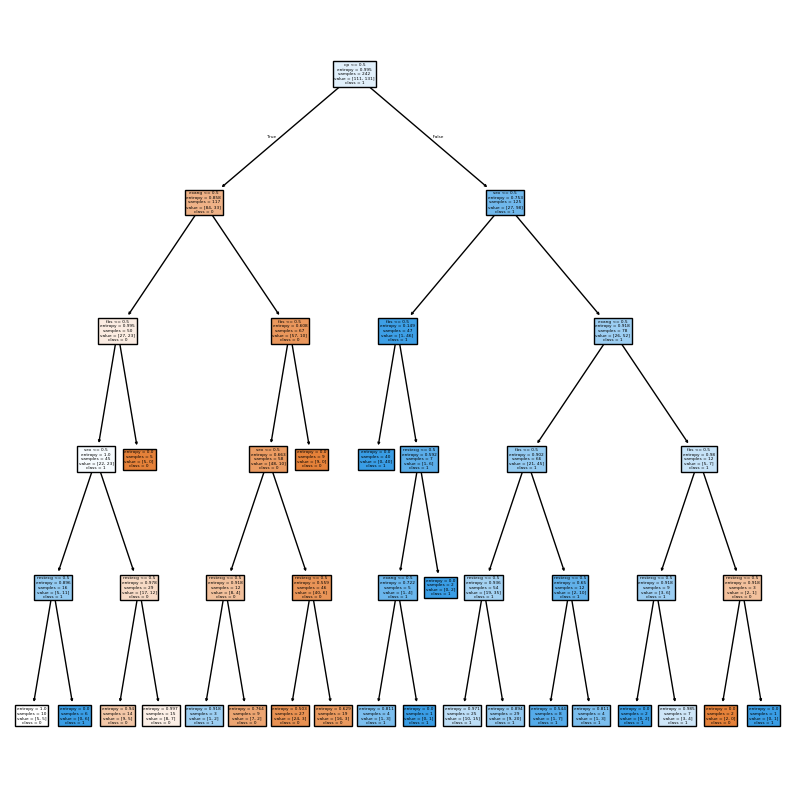

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 10), dpi=100) # Визначення розміру дерева
tree.plot_tree(clftree1, feature_names=list(df1.columns), class_names=["0", "1"], filled=True) # Визначення параметрів дерева
fig.savefig("imagename1.png")  # Збереження дерева



---



Виконаємо
перехресну перевірку і оцінимо її помилку при різних значеннях штрафу на складність
моделі



---



Задайте діапазон значень min_samples_split, які ви хочете перевірити.<br>
Для прикладу візьмемо: від 0.1 до 1.0 з кроком 0.1

In [ ]:
min_samples_split_range = np.arange(0.1, 1.1, 0.2)



---



Стовримо масив для збереження помилок кожного значення min_samples_split


In [ ]:
cv_errors = []



---



Далі перебираємо всі значення значення <b>min_samples_split</b>(використаємо крос-перевірку для кожного значення)

In [ ]:
for min_samples_split_val in min_samples_split_range:
    clftree = DecisionTreeClassifier(criterion="entropy", min_samples_split=min_samples_split_val) # Визначення моделі

    scores = cross_val_score(clftree, X_train, Y_train, cv=5) # Визначення параметрів крос-перевірки

    cv_errors.append(1 - np.mean(scores)) # Зберігання помилок



---



Знайдемо оптимальне значення min_samples_split(значення, яке мінімізує помилку крос-перевірки)


In [ ]:
optimal_min_samples_split = min_samples_split_range[np.argmin(cv_errors)]
min_cv_error = np.min(cv_errors)



---



Будуємо графік та виводимо данні

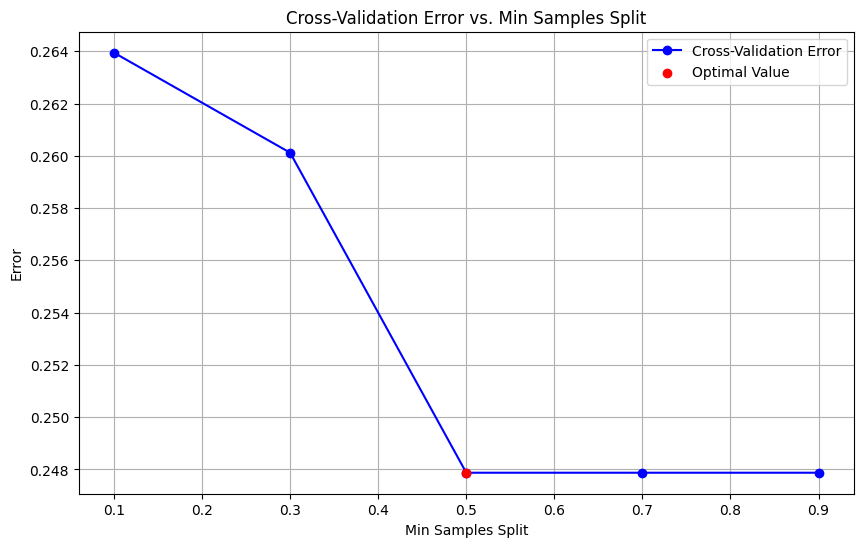

Optimal Min Samples Split: 0.5000000000000001
Minimum Cross-Validation Error: 0.24787414965986387


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(min_samples_split_range, cv_errors, marker='o', linestyle='-', color='b', label='Cross-Validation Error')
plt.scatter(optimal_min_samples_split, min_cv_error, color='r', label='Optimal Value', zorder=5)
plt.title('Cross-Validation Error vs. Min Samples Split')
plt.xlabel('Min Samples Split')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimal Min Samples Split: {optimal_min_samples_split}")
print(f"Minimum Cross-Validation Error: {min_cv_error}")



---



На графіку видно, що мінімум відносної помилки при перехресній перевірці
приблизно припадає на значення <b>ср</b> = 0.24. Виконаємо обрізку дерева при цьому значенні:



---



Обріжемо дерево за оптимальним значенням <b>min_samples_split</b>(значення, яке мінімізує помилку крос-перевірки) та виведемо точність:


In [ ]:
clftree = DecisionTreeClassifier(criterion="entropy", min_samples_split=optimal_min_samples_split)
clftree.fit(X_train, Y_train)
pred = clftree.predict(X_test)
accuracy_score = accuracy_score(Y_test, pred)
print(accuracy_score)

0.7868852459016393




---



Візуалізумо обрізане дерево рішень:

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5), dpi=150)
tree.plot_tree(clftree, feature_names=list(df1.columns), class_names=["0", "1"], filled=True)
fig.savefig('imagename3.jpeg.png')
plt.show()

NameError: name 'plt' is not defined